# Algorithm Usage Example

This notebook shows how to import the algorithms and run it for a simple rectangular BPSK.

In [29]:
# Import the algorithms
from scf_test import ssca, fam, fast_sc_wrapper, scf_2d_fft_wrapper
from algorithm.s3ca import s3ca

# Import BPSK signal creation for example runs. Other signals creation are also avalable
from scf_test.psk import create_rect_bpsk_signal

# Utility functions for plotting Power Spectral Density(PSD) and Cyclic Domain Profile (CDP) respectively
from scf_test import psd, plot_cdp

# Utility functions for adding carrier frequency offset (CFO) and noise to the signal
from scf_test.tests import add_cfo, add_awgn_snr
from scf_test.psk import plot_signal 


The main API of the algorithms are as follows:

`Sx, f, alpha = scd_algorithm(signal, Np=64, conjugate=False, coherence=False)`

or if it is the FFT-Accumulation Method (FAM), then a hop parameter is included of which the default value is usually Np/4 (an exception will be explained later):

`Sx, f, alpha = fam(signal, Np=64, L=16, conjugate=False, coherence=False)`

where *Sx* is a complex, and the frequency and cycle frequency mappings are in *f* and *alpha*.


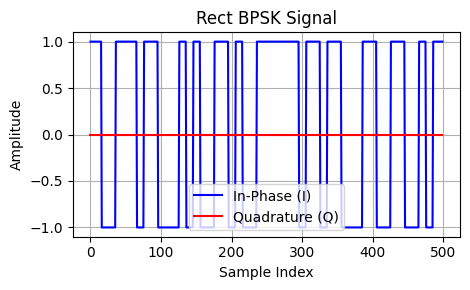

In [ ]:
# Create a simple BPSK signal with CFO and noise
N = 4096
sps = 10
snr = 10 # dB
cfo = 0.05 
fs  = 1 # Normalized 
rng = np.random.default_rng(10)

bpsk_sig = create_rect_bpsk_signal(number_of_symbols=1000, samples_per_symbol=sps, plot=True, rng=rng)[:N]

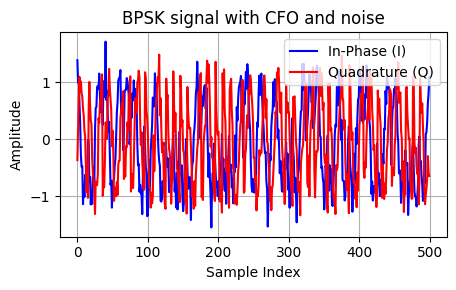

In [31]:
bpsk_sig = add_cfo(bpsk_sig, cfo)
bpsk_sig = add_awgn_snr(bpsk_sig, snr)
plot_signal(bpsk_sig, title='BPSK signal with CFO and noise')

### Running the algorithms

In [32]:
Sx_ssca, f_ssca, alpha_ssca = ssca(bpsk_sig)
Sx_fam, f_fam, alpha_fam = fam(bpsk_sig)
Sx_fastsc, f_fastsc, alpha_fastsc = fast_sc_wrapper(bpsk_sig)
Sx_2dfft, f_2dfft, alpha_2dfft = scf_2d_fft_wrapper(bpsk_sig)
Sx_s3ca, f_s3ca, alpha_s3ca = s3ca(bpsk_sig)
ref_psd = psd(bpsk_sig, method='welch', L=64)

### Quick Verification

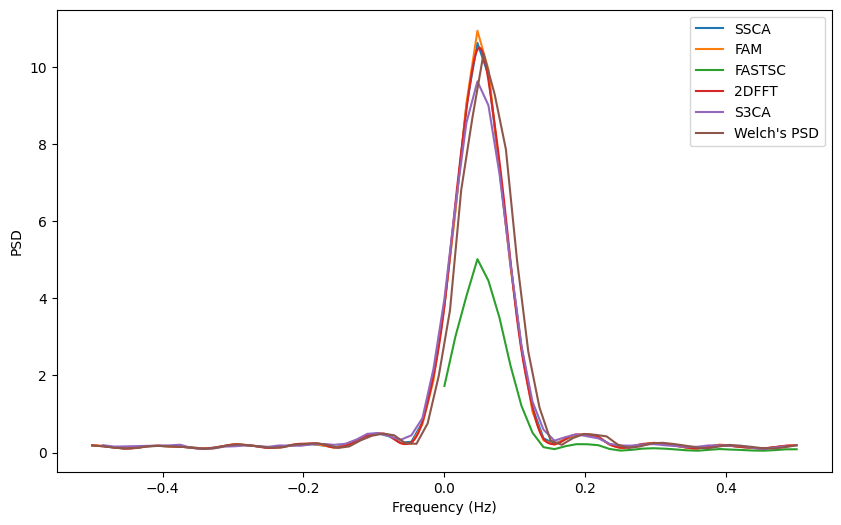

In [33]:
# Plotting the alpha = 0 slice and compared against Welch's PSD estimate
import matplotlib.pyplot as plt

psd_ssca = np.abs(Sx_ssca[np.abs(alpha_ssca) < 1e-6])
psd_fam = np.abs(Sx_fam[np.abs(alpha_fam) < 1e-6])
psd_fastsc = np.abs(Sx_fastsc[np.abs(alpha_fastsc) < 1e-6])
psd_2dfft = np.abs(Sx_2dfft[np.abs(alpha_2dfft) < 1e-6])
psd_s3ca = np.abs(Sx_s3ca[np.abs(alpha_s3ca) < 1e-6])

f_welch = np.linspace(-0.5, 0.5, len(ref_psd))

plt.figure(figsize=(10, 6))
plt.plot(f_ssca[np.abs(alpha_ssca) < 1e-6], psd_ssca, label='SSCA')
plt.plot(f_fam[np.abs(alpha_fam) < 1e-6], psd_fam, label='FAM')
plt.plot(f_fastsc[np.abs(alpha_fastsc) < 1e-6], psd_fastsc, label='FASTSC')
plt.plot(f_2dfft[np.abs(alpha_2dfft) < 1e-6], psd_2dfft, label='2DFFT')
plt.plot(f_s3ca[np.abs(alpha_s3ca) < 1e-6], psd_s3ca, label='S3CA')
plt.plot(f_welch, ref_psd, label='Welch\'s PSD')

plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.legend()
plt.show()


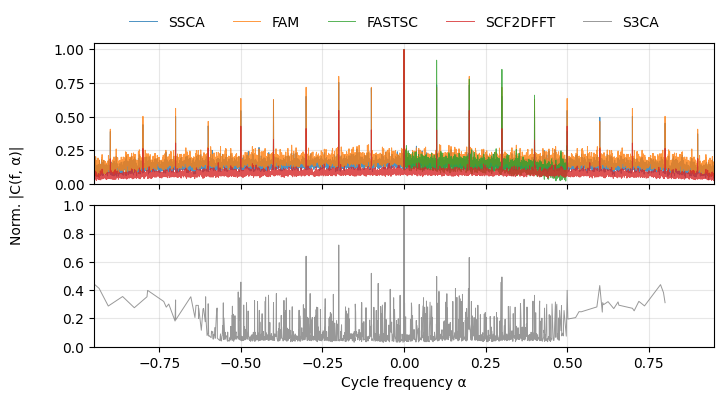

In [34]:
# Plot CDP
from scf_test import spectral_correlation_to_coherence

coh_ssca = spectral_correlation_to_coherence(ref_psd, Sx_ssca, f_ssca, alpha_ssca)
coh_fam = spectral_correlation_to_coherence(ref_psd, Sx_fam, f_fam, alpha_fam)
coh_fastsc = spectral_correlation_to_coherence(ref_psd, Sx_fastsc, f_fastsc, alpha_fastsc)
coh_s3ca = spectral_correlation_to_coherence(ref_psd, Sx_s3ca, f_s3ca, alpha_s3ca)
coh_2dfft = spectral_correlation_to_coherence(ref_psd, Sx_2dfft, f_2dfft, alpha_2dfft)

# For FastSC, we need to use the built in coherence option to get correct peaks
coh_fastsc, _, _ = fast_sc_wrapper(bpsk_sig, coherence=True)

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.15})

plot_cdp(
    {'SSCA': (coh_ssca, alpha_ssca),
     'FAM': (coh_fam, alpha_fam),
     'FASTSC': (coh_fastsc, alpha_fastsc),
     'SCF2DFFT': (coh_2dfft, alpha_2dfft)
     },
    ax=axes[0],
    normalize=True,
    alpha_range=(-0.95, 0.95)
)

# Optional adjustments to make the plot look better
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel('')
axes[0].set_ylabel('')

plot_cdp(
    {'S3CA': (coh_s3ca, alpha_s3ca)},
    ax=axes[1],
    normalize=True,
    alpha_range=(-0.95, 0.95)
)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('')

# Force S3CA to a non-blue color
for line in axes[1].get_lines():
    line.set_color('C7')   # purple. Try C5, C6, C7 too.

fig.supylabel('Norm. |C(f, α)|', fontsize=10)
# Collect handles and labels from both axes
all_handles = []
all_labels = []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    all_handles.extend(h)
    all_labels.extend(l)

# Single shared legend at the top of the figure
fig.legend(all_handles, all_labels,
           loc='upper center', ncol=5,
           bbox_to_anchor=(0.5, 0.98), fontsize=10,
           frameon=False)

# Remove the per-axis legends since the figure-level one replaces them
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

plt.subplots_adjust(top=0.88, bottom=0.12)